# MFE 230X Final Project, Part 1: Speed

Based on Scholtus and van Dijk (2012), *High-Frequency Technical Trading: The Importance of Speed*.

| Choice | Value |
|---|---|
| Liquid equity | AAPL (Nasdaq) |
| Less liquid equity | GPRO (Nasdaq) |
| FX pair | EUR/USD |
| Period | September 2019, 20 trading days (3 to 30 September) |
| Signals from the paper | Moving average (MA), on-balance volume (OBV) |
| Own signal | Persistent best-quote imbalance (IMB) |
| Execution delays | 0 ms, 100 ms, 1 second |
| Book | $1,000,000 |

3 assets x 3 signals x 3 delays = **27 profit-and-loss reports** (section 3).

**Trading procedure (paper, section 3.1).** A signal in {-1, 0, +1} is built every 60 seconds from the information available at the interval change. The order it implies is executed `delay` later against the best quote prevailing at that moment: buys pay the ask, sells receive the bid. No position is opened in the first 10 minutes of the session, and everything is unwound 10 minutes before the close. Each round trip commits the full $1,000,000 and returns are summed without compounding (paper eq. 1 and 2), so the total return is the sum of round-trip returns and the P&L is that sum times $1,000,000. The bid-ask spread is the only transaction cost.

**Main results.**

1. All 27 strategies lose money once the spread is paid. The loss is almost entirely the spread: about 0.3 bps per round trip on EUR/USD, 0.7 bps on AAPL and 22.5 bps on GPRO.
2. The cost of delay is small next to the spread: at most 0.06 bps per round trip for eight of the nine baseline strategies at both delays. The exception is the imbalance signal on GPRO, which gives up 0.33 bps per round trip ($26,198 over the month) with a 1 second delay.
3. Delay is not always a cost. On AAPL the rules lose money, and a delay of 10 to 500 ms makes them lose 1 to 7% less (significant). This is the paper's finding for losing strategies.
4. Tick frequency sets how often a delayed order meets a different quote (62% of the time after 1 second on AAPL, 55% on EUR/USD, 1% on GPRO); tick size relative to price sets how much each miss costs (22 bps on GPRO). Sensitivity to delay is the product of the two.

All the logic lives in `src/speed.py`; this notebook runs it and reports the results.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "src")
import speed

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
OUT = Path("outputs"); FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)

ASSETS = ["AAPL", "GPRO", "EURUSD"]
SIGNALS = ["MA", "OBV", "IMB"]
ASSET_COLOR = {"AAPL": "#2a78d6", "GPRO": "#eb6834", "EURUSD": "#1baf7a"}   # identity
DELAY_COLOR = {0: "#86b6ef", 100: "#2a78d6", 1000: "#0d366b"}                # magnitude: one hue, light to dark
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})

In [2]:
%%time
res, micro = speed.run_all(ASSETS)
res.to_csv(OUT / "daily_results_all_rules.csv", index=False)
print(f"{len(res):,} asset / rule / delay / day results;", res.groupby("asset", sort=False).date.nunique().to_dict(), "trading days")

14,400 asset / rule / delay / day results; {'AAPL': 20, 'GPRO': 20, 'EURUSD': 20} trading days
CPU times: user 16.6 s, sys: 961 ms, total: 17.6 s
Wall time: 17.6 s


## 1. Data, liquidity and tick frequency

- **Equities.** Databento Nasdaq TotalView-ITCH, MBP-1 schema: every trade and every change of the best bid and offer, nanosecond stamps. Session 09:30 to 16:00 New York time (13:30 to 20:00 UTC).
- **EUR/USD.** Dukascopy tick data: every change of the best bid/ask with the quoted sizes, millisecond stamps (`src/download_fx.py`). It is evaluated over the same 13:30 to 20:00 UTC window and the same 20 days, so the three assets face the same clock and the same number of signals.

Limits of the data:

1. MBP-1 only shows the top of the book. A $1,000,000 order is far larger than the displayed size at the best quote (about 225 AAPL shares, roughly $49,000), so the P&L assumes the whole order fills at the best quote. The paper walks the book for each capacity level; that needs depth data we do not have here.
2. Spot FX has no public trade tape. For EUR/USD the volume input of OBV is tick volume: one unit for each quote that moves the mid.
3. Dukascopy is one venue's feed, so its tick frequency understates the whole EUR/USD market.

In [3]:
liq = micro.groupby("asset", sort=False).mean(numeric_only=True)
table1 = pd.DataFrame({
    "Mid price": liq.mid,
    "Quoted spread (bps)": liq.spread_bps,
    "Quoted spread (price units)": liq.spread_ticks,
    "Depth at best (units)": liq.depth,
    "BBO updates per second": liq.bbo_updates_per_s,
    "Quote price changes per second": liq.quote_moves_per_s,
    "Trades per second": liq.trades_per_s,
    "1-minute volatility (bps)": liq.vol_1min_bps,
    "P(quote changes within 100 ms)": liq.p_quote_change_100ms,
    "P(quote changes within 1 s)": liq.p_quote_change_1000ms,
    "Mean |mid move| after 100 ms (bps)": liq.abs_mid_move_100ms_bps,
    "Mean |mid move| after 1 s (bps)": liq.abs_mid_move_1000ms_bps,
}).T[ASSETS]
table1.loc["Trades per second", "EURUSD"] = np.nan   # no FX trade tape: the OBV input there is tick volume
table1.to_csv(OUT / "table1_liquidity_tick_frequency.csv")
table1.style.format("{:,.4f}", na_rep="n/a")

asset,AAPL,GPRO,EURUSD
Mid price,217.8983,4.5095,1.1011
Quoted spread (bps),0.7335,22.5184,0.2703
Quoted spread (price units),0.0160,0.0101,0.0000
Depth at best (units),225.3725,"4,944.7814",1.6738
BBO updates per second,40.0641,1.7673,1.4444
Quote price changes per second,8.7970,0.0399,1.2063
Trades per second,3.4544,0.1148,n/a
1-minute volatility (bps),5.3174,16.9705,1.1432
P(quote changes within 100 ms),0.2555,0.0023,0.1496
P(quote changes within 1 s),0.6218,0.0113,0.5503


**Reading the table.** The three assets differ on two separate dimensions.

- *Cost of trading.* EUR/USD is the cheapest (0.27 bps quoted spread), AAPL close behind (0.73 bps), GPRO about 30 times more expensive than AAPL (22.5 bps). GPRO trades near $4.50, so the one-cent minimum tick alone is 22 bps of the price: its spread is pinned at one tick.
- *Tick frequency.* AAPL's best quote changes price 8.8 times per second, EUR/USD 1.2 times, GPRO once every 25 seconds. As a result the quote a delayed order meets differs from the one the signal saw 62% of the time after 1 second on AAPL, 55% on EUR/USD and 1.1% on GPRO.

## 2. The three signals

Inputs are sampled at each one-minute interval change $t$: the mid quote $m_t$, the on-balance volume $obv_t$ and the imbalance $I_t$. With $ma_t(n, x)$ the average of the last $n$ values of $x$:

**MA (paper eq. 3).** Long if $ma_t(s,m) > (1+b)\,ma_t(l,m)$, short if $ma_t(s,m) < (1-b)\,ma_t(l,m)$, flat otherwise. Baseline $s=2$, $l=10$, $b=0.5$ bp.

**OBV (paper eq. 6).** $obv_t$ is the running sum since the open of trade volume signed by the tick rule (+ on an uptick, - on a downtick; auction crosses excluded). Long if $ma_t(s,obv) > ma_t(l,obv) + band$, short if $ma_t(s,obv) < ma_t(l,obv) - band$. The paper's band is proportional to the level; because OBV restarts at zero every day and changes sign, the band here is $b$ times the average one-minute volume over the long window. Baseline $s=2$, $l=10$, $b=0.05$.

**IMB (own signal): persistent best-quote imbalance.** At every instant the queue imbalance is $(q^{bid}-q^{ask})/(q^{bid}+q^{ask})$ with $q$ the size at the best bid and ask. $I_t$ is its time-weighted average over the minute ending at $t$. Long if $I > \theta$ in each of the last $k$ minutes, short if $I < -\theta$ in each of them, flat otherwise. Baseline $k=2$, $\theta=0.2$. The idea: a queue that stays heavier on the bid for whole minutes signals buying pressure that has not yet moved the price; requiring persistence filters the flickering that dominates instantaneous imbalance.

The baseline parameters are round, mid-range values and were not tuned to improve the P&L. For the Figure 6 style analysis each family is widened to 9 parameter sets (27 rules per asset), listed in `speed.UNIVERSE`.

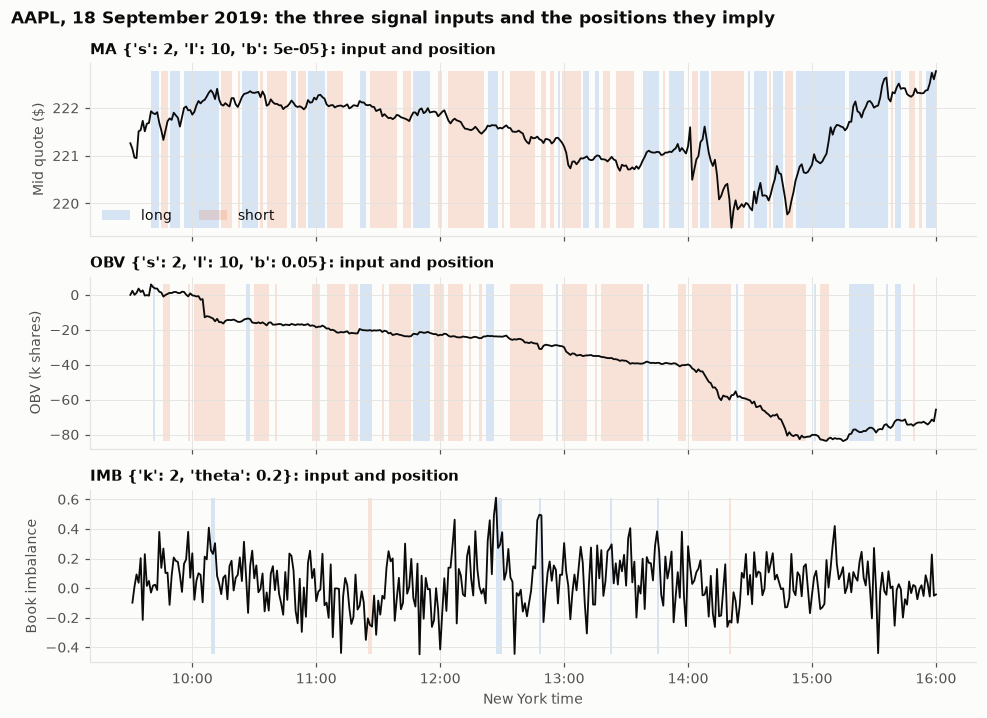

In [4]:
day = speed.load_equity_day("20190918")["AAPL"]      # FOMC day
f = speed.features(day)
t = pd.to_datetime(f["grid"]).tz_localize("UTC").tz_convert("America/New_York").tz_localize(None)
fig, axes = plt.subplots(3, 1, figsize=(9, 6.6), sharex=True)
panels = [("MA", f["mid"], "Mid quote ($)"), ("OBV", f["obv"] / 1e3, "OBV (k shares)"),
          ("IMB", f["imb"], "Book imbalance")]
for ax, (name, y, lab) in zip(axes, panels):
    fn, prm = speed.BASELINE[name]
    sig = fn(f, **prm)
    ax.plot(t, y, color=INK, lw=1.2)
    lo, hi = np.nanmin(y), np.nanmax(y)
    ax.fill_between(t, lo, hi, where=sig == 1, color="#2a78d6", alpha=0.18, lw=0, step="post", label="long")
    ax.fill_between(t, lo, hi, where=sig == -1, color="#eb6834", alpha=0.18, lw=0, step="post", label="short")
    ax.set_title(f"{name} {prm}: input and position", loc="left"); ax.set_ylabel(lab)
axes[0].legend(loc="lower left", ncol=2)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); axes[-1].set_xlabel("New York time")
fig.suptitle("AAPL, 18 September 2019: the three signal inputs and the positions they imply", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "01_signals_example_day.png"); plt.show()

## 3. The 27 profit-and-loss reports

One line per asset / signal / delay. *P&L at mid* values the same trades at the mid quote, so *Spread paid* = P&L at mid - P&L is what crossing the spread cost.

In [5]:
rep = speed.pnl_report(res)
rep.to_csv(OUT / "table2_pnl_reports_27.csv", index=False)
cols = {"pnl": "P&L ($)", "total_return_pct": "Total return (%)", "final_book": "Final book ($)",
        "pnl_mid": "P&L at mid ($)", "spread_paid": "Spread paid ($)", "round_trips": "Round trips",
        "bps_per_trip": "Net bps / trip", "win_rate_pct": "Win rate (%)",
        "best_day": "Best day ($)", "worst_day": "Worst day ($)", "daily_std": "Daily std ($)"}
show = rep.rename(columns={"asset": "Asset", "family": "Signal", "delay_ms": "Delay (ms)", **cols})
show = show.set_index(["Asset", "Signal", "Delay (ms)"])[list(cols.values())]
print(len(show), "profit-and-loss reports")
show.style.format("{:,.0f}").format("{:,.2f}", subset=["Total return (%)", "Net bps / trip", "Win rate (%)"])

27 profit-and-loss reports


In [6]:
pnl = rep.pivot_table(index=["asset", "family"], columns="delay_ms", values="pnl", sort=False)
pnl.columns = [f"P&L at {c} ms ($)" for c in pnl.columns]
pnl.style.format("{:,.0f}")

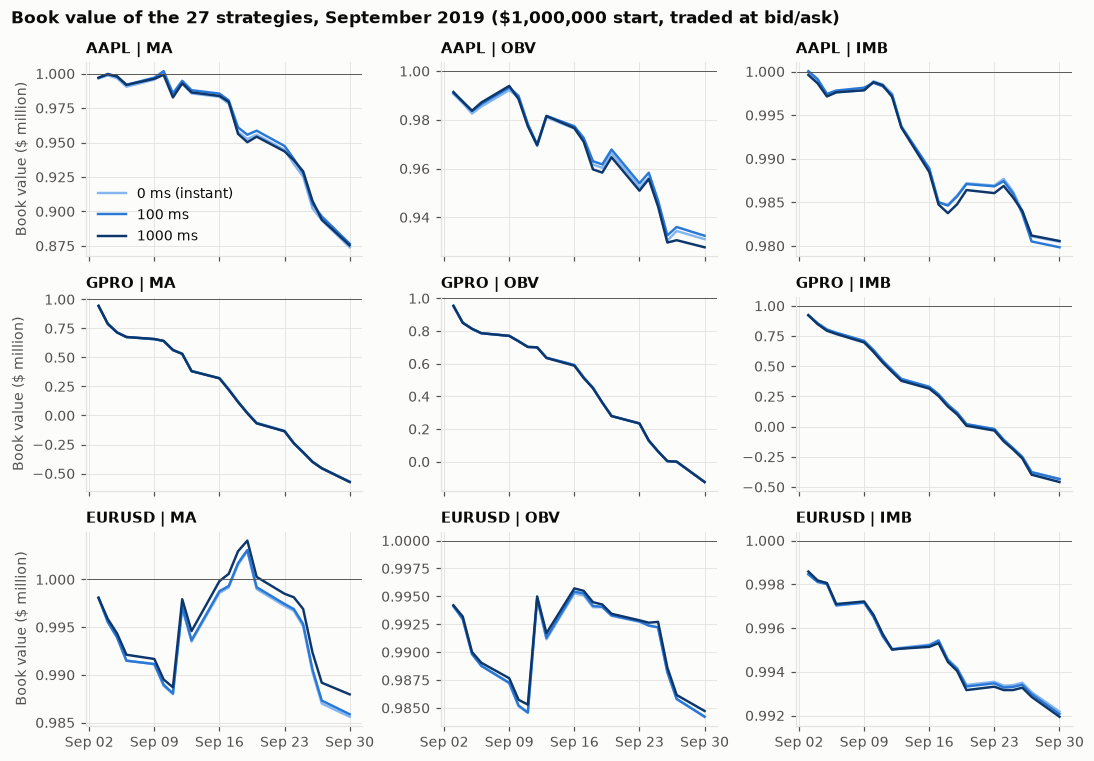

In [7]:
b = res[(res.kind == "baseline") & res.delay_ms.isin(speed.DELAYS_MS)]
fig, axes = plt.subplots(3, 3, figsize=(10, 7), sharex=True)
for i, a in enumerate(ASSETS):
    for j, s in enumerate(SIGNALS):
        ax = axes[i, j]
        for d in speed.DELAYS_MS:
            x = b[(b.asset == a) & (b.family == s) & (b.delay_ms == d)].sort_values("date")
            ax.plot(x.date, speed.BOOK / 1e6 + x.pnl.cumsum() / 1e6, color=DELAY_COLOR[d], lw=1.6,
                    label=f"{d} ms" if d else "0 ms (instant)")
        ax.axhline(1, color=MUTED, lw=0.6)
        ax.set_title(f"{a} | {s}", loc="left")
        if j == 0: ax.set_ylabel("Book value ($ million)")
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0, 0].legend(loc="lower left")
fig.suptitle("Book value of the 27 strategies, September 2019 ($1,000,000 start, traded at bid/ask)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "02_book_value_27_strategies.png"); plt.show()

**What the reports show.**

- **Every strategy loses money net of the spread.** Total returns range from -0.8% (EUR/USD, IMB) to -157% (GPRO, MA). A GPRO book below zero is an artefact of the paper's convention: $1,000,000 is committed to every round trip without compounding, and 700 round trips at 22.5 bps each cost more than the book.
- **The loss is the spread.** Valued at the mid, AAPL IMB is about flat (-$1,293), EUR/USD MA and OBV earn about +$10,000, and GPRO OBV and IMB earn +$145,000 and +$324,000. Those gross profits are a fraction of the spread paid ($25,000 on EUR/USD, $1.3 to 1.8 million on GPRO). One-minute technical signals do not predict enough to pay for taking liquidity on every trade, which is consistent with the paper's choice to study speed and not absolute profitability.
- **The delay lines are almost on top of each other.** Within each panel the three delays differ by far less than the strategy loses. Section 4 measures that difference.

## 4. Cost of delay

Cost of delay = P&L with instantaneous execution - P&L with the delayed execution, for the same signal. Positive means the delay hurts. The Wilcoxon signed-rank test is run on the 20 daily differences (not reported when fewer than 6 days differ).

In [8]:
cod = speed.cost_of_delay(res)
cod.to_csv(OUT / "table3_cost_of_delay_baseline.csv", index=False)
cod.rename(columns={"asset": "Asset", "family": "Signal", "delay_ms": "Delay (ms)", "pnl_0ms": "P&L 0 ms ($)",
                    "pnl_delayed": "P&L delayed ($)", "cost_usd": "Cost of delay ($)",
                    "cost_bps_per_trip": "Cost (bps / trip)", "cost_pct_of_abs_pnl": "Cost (% of |P&L 0 ms|)",
                    "days_worse": "Days worse", "days_better": "Days better", "wilcoxon_p": "Wilcoxon p"}
           ).set_index(["Asset", "Signal", "Delay (ms)"]).style.format("{:,.0f}").format(
    "{:,.3f}", subset=["Cost (bps / trip)", "Cost (% of |P&L 0 ms|)", "Wilcoxon p"])

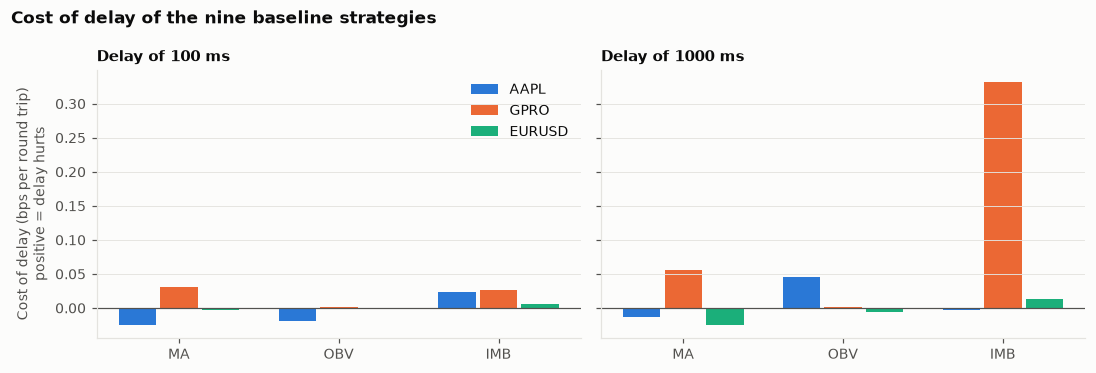

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
w = 0.26
for ax, d in zip(axes, (100, 1000)):
    for k, a in enumerate(ASSETS):
        y = cod[(cod.asset == a) & (cod.delay_ms == d)].set_index("family").cost_bps_per_trip.reindex(SIGNALS)
        ax.bar(np.arange(3) + (k - 1) * w, y, w * 0.9, color=ASSET_COLOR[a], label=a)
    ax.axhline(0, color=MUTED, lw=0.8); ax.set_xticks(range(3)); ax.set_xticklabels(SIGNALS)
    ax.set_title(f"Delay of {d} ms", loc="left"); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Cost of delay (bps per round trip)\npositive = delay hurts"); axes[0].legend()
fig.suptitle("Cost of delay of the nine baseline strategies", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "03_cost_of_delay_baseline.png"); plt.show()

**Baseline strategies.**

- Eight of the nine strategies have a cost of delay between -0.03 and +0.06 bps per round trip at both delays, and most are statistically indistinguishable from zero. In dollars the largest of them is $3,980 on a $1,000,000 book over a month.
- **GPRO with the imbalance signal** is the exception: a 1 second delay costs $26,198, or 0.33 bps per round trip, with 9 days worse against 3 better (p = 0.052). This is the one strategy whose signal has real gross value (+$324,000 at mid), and that value decays within the second.
- **EUR/USD with MA** goes the other way: a 1 second delay improves the P&L by $2,345 (16 days better out of 20, p = 0.003).
- Against the spread these are small: the 1 second cost on GPRO IMB is 1.5% of the spread that strategy pays.

### Figure 6 of the paper: importance of speed

As in the paper, each day the average return across rules with delay $d$ is compared with the average under instantaneous execution, in percent of the latter, and the daily figures are averaged over the 20 days. A **negative** value means delay lowers performance. The universe is 27 rules per asset (9 parameter sets per family), with the paper's eight delay levels.

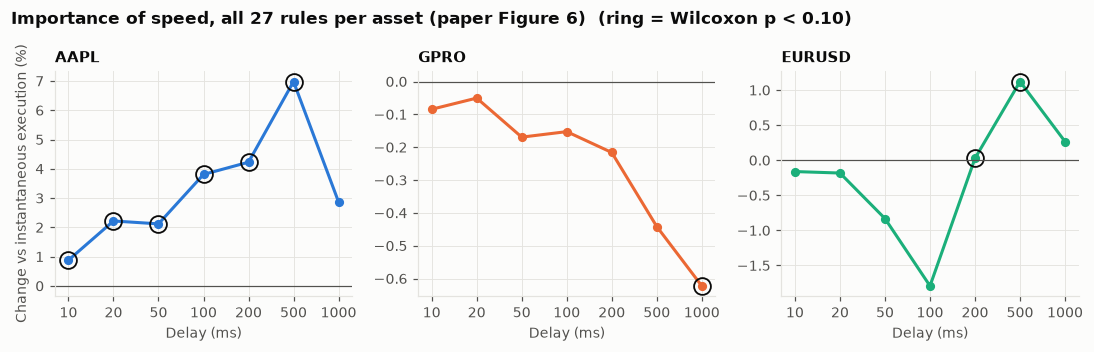

In [10]:
ios = {k: speed.importance_of_speed(res, subset=k) for k in ("all", "positive", "negative")}
pd.concat(ios, names=["strategies"]).reset_index(level=0).to_csv(OUT / "table4_importance_of_speed.csv", index=False)

def fig6(tab, title, fname):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    for ax, a in zip(axes, ASSETS):
        x = tab[tab.asset == a]
        pos = np.arange(len(x))
        ax.plot(pos, x.importance_pct, color=ASSET_COLOR[a], marker="o", ms=5)
        sigp = x.wilcoxon_p.to_numpy() < 0.10
        ax.plot(pos[sigp], x.importance_pct.to_numpy()[sigp], ls="", marker="o", ms=11, mfc="none", mec=INK, mew=1.2)
        ax.axhline(0, color=MUTED, lw=0.8)
        ax.set_xticks(pos); ax.set_xticklabels(x.delay_ms); ax.set_xlabel("Delay (ms)")
        ax.set_title(a, loc="left")
    axes[0].set_ylabel("Change vs instantaneous execution (%)")
    fig.suptitle(title + "  (ring = Wilcoxon p < 0.10)", x=0.01, ha="left", fontweight="bold")
    fig.tight_layout(); fig.savefig(FIG / fname); plt.show()

fig6(ios["all"], "Importance of speed, all 27 rules per asset (paper Figure 6)", "04_importance_of_speed_all.png")
ios["all"].query("delay_ms in (100, 1000)").set_index(["asset", "delay_ms"]).style.format("{:,.3f}")

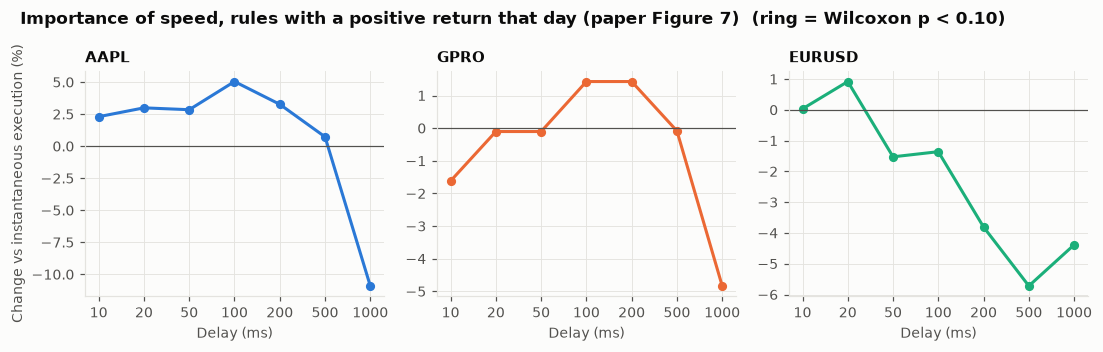

In [11]:
fig6(ios["positive"], "Importance of speed, rules with a positive return that day (paper Figure 7)", "05_importance_of_speed_positive.png")
pd.concat({k: v.query("delay_ms in (100, 1000)").set_index(["asset", "delay_ms"])[["importance_pct", "pooled_pct", "diff_bps_per_day", "n_days", "wilcoxon_p"]]
           for k, v in ios.items()}, axis=1).style.format("{:,.3f}")

**Reading the Figure 6 results.**

- **AAPL: delay helps the losing rules.** Performance improves by 0.9% at 10 ms up to 7.0% at 500 ms, significant at every level up to 500 ms (3.8% at 100 ms, p = 0.03), then falls back to 2.9% at 1 second (not significant). The rules lose money on average, so they are on the wrong side of the next short-horizon move: they buy after the mid has risen over the minute, and part of that move reverts in the following few hundred milliseconds. Arriving late means trading at a slightly better price. The paper documents the same effect for its losing strategies and attributes the split to selection.
- **AAPL, profitable rule-days only.** The sign flips at 1 second: -10.9% on average (median -3.8%), in the paper's direction, but with only 16 days it is not significant.
- **GPRO: delay hurts, slowly.** The loss grows steadily with delay, from -0.08% at 10 ms to -0.62% at 1 second (p = 0.08). In percent it looks small because the benchmark return is a very large loss; in return terms it is 3.5 bps per rule-day, the largest of the three assets.
- **EUR/USD: no clear effect.** Slightly negative up to 100 ms (-1.8%, not significant), slightly positive beyond.

The paper finds that 200 ms is enough to hurt profitable strategies on SPY, QQQQ and IWM. With 20 days and 27 rules per asset the power here is much lower than the paper's 186 days and 27,424 rules, and most of our rule-days are losing ones, so the clean comparison is with the paper's negative-strategy panel, which our AAPL result matches.

## 5. Do signals behave differently across market conditions?

Days are split, asset by asset, into the 10 most and 10 least volatile (one-minute mid-quote volatility). Costs are in bps of the book per rule-day; *abs effect* is the mean absolute change in return from a 1 second delay, per round trip, which measures sensitivity regardless of sign.

In [12]:
u = res[res.kind == "universe"]
wide = u.pivot_table(index=["asset", "family", "params", "date"], columns="delay_ms", values="ret", sort=False)
wide = wide[wide[0] != 0]
trips = u[u.delay_ms == 0].set_index(["asset", "family", "params", "date"]).n_trips.reindex(wide.index)
grp = lambda x: x.groupby(level=["asset", "date"], sort=False)
d = wide.groupby(level=["asset", "date"], sort=False).mean()
daily = pd.DataFrame({"ret0_bps": d[0] * 1e4, "cost100_bps": (d[0] - d[100]) * 1e4, "cost1000_bps": (d[0] - d[1000]) * 1e4,
                      "trips_per_rule": grp(trips).mean(),
                      "abs100_bps": grp((wide[100] - wide[0]).abs()).sum() / grp(trips).sum() * 1e4,
                      "abs1000_bps": grp((wide[1000] - wide[0]).abs()).sum() / grp(trips).sum() * 1e4})
daily = daily.join(micro.set_index(["asset", "date"]))
daily["vol_regime"] = daily.groupby(level="asset", sort=False).vol_1min_bps.transform(lambda x: np.where(x > x.median(), "high vol", "low vol"))
daily.to_csv(OUT / "daily_cost_and_microstructure.csv")
cond = daily.groupby(["asset", "vol_regime"], sort=False).agg(
    days=("ret0_bps", "size"), vol_1min_bps=("vol_1min_bps", "mean"), spread_bps=("spread_bps", "mean"),
    quote_changes_per_s=("quote_moves_per_s", "mean"), ret0_bps_per_day=("ret0_bps", "mean"),
    cost100_bps_per_day=("cost100_bps", "mean"), cost1000_bps_per_day=("cost1000_bps", "mean"),
    abs_effect_1s_bps_per_trip=("abs1000_bps", "mean")).reindex(ASSETS, level=0)
cond.to_csv(OUT / "table5_volatility_regimes.csv")
cond.style.format("{:,.3f}")

In [13]:
fam = speed.importance_of_speed(res, by=("asset", "family")).query("delay_ms in (100, 1000)")
fam.to_csv(OUT / "table6_importance_by_signal_family.csv", index=False)
bysig = wide.assign(c100=(wide[0] - wide[100]) * 1e4, c1000=(wide[0] - wide[1000]) * 1e4,
                    a1000=(wide[1000] - wide[0]).abs() * 1e4, r0=wide[0] * 1e4).groupby(level=["asset", "family"], sort=False)[["r0", "c100", "c1000", "a1000"]].mean()
bysig.columns = ["Return at 0 ms (bps/day)", "Cost 100 ms (bps/day)", "Cost 1 s (bps/day)", "Mean |effect| 1 s (bps/day)"]
bysig.to_csv(OUT / "table6b_cost_by_signal_family_bps.csv")
bysig.style.format("{:,.3f}")

**Market conditions.**

- **Sensitivity to delay rises with volatility on all three assets.** The absolute effect of a 1 second delay per round trip is 0.24 bps on AAPL's volatile days against 0.13 bps on quiet days, 0.40 against 0.26 on GPRO, 0.037 against 0.030 on EUR/USD. Day by day, the correlation between this sensitivity and one-minute volatility is 0.58 to 0.67. The quote moves further during the delay when the market is moving faster.
- **The signed cost follows where the signal has value.** On GPRO a 1 second delay costs 6.9 bps per rule-day on volatile days and 0.1 bps on quiet days: the imbalance signal's edge and its decay are concentrated on active days. On AAPL the benefit of waiting 1 second is confined to quiet days (-1.9 bps cost); on volatile days it turns into a small cost (+0.6 bps). The paper finds the opposite ordering for SPY (speed matters more on low-volatility days), on a sample of profitable strategies.
- **By signal family.** The imbalance signal is the most delay-sensitive on GPRO (8.0 bps per day at 1 second, against 0.7 for MA and 1.8 for OBV). It is built from the state of the queue, which is exactly what changes when the best quote is taken out. MA and OBV are built from one-minute averages and move little in one second. On AAPL and EUR/USD no family shows a consistent cost.

## 6. Tick frequency and the importance of delay

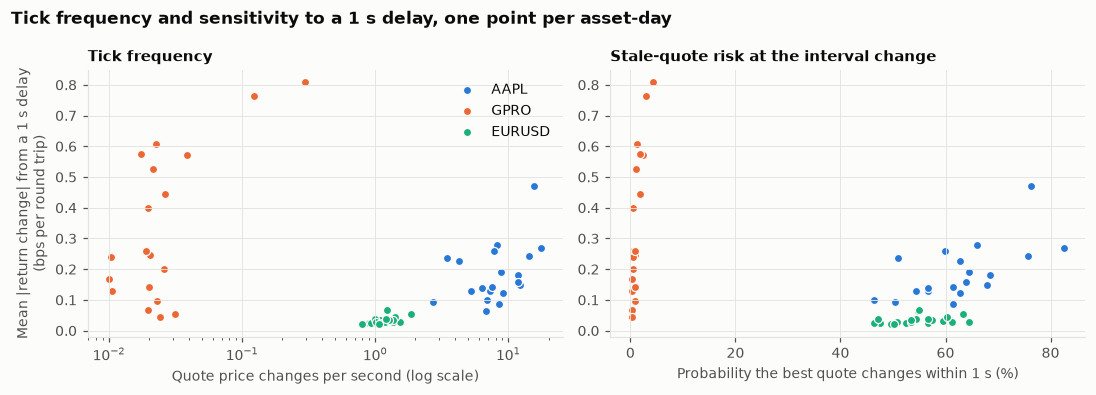

asset,AAPL,GPRO,EURUSD
quote_moves_per_s,8.7970,0.0399,1.2063
p_quote_change_100ms,0.2555,0.0023,0.1496
p_quote_change_1000ms,0.6218,0.0113,0.5503
abs_mid_move_100ms_bps,0.1117,0.0444,0.0122
abs_mid_move_1000ms_bps,0.4804,0.2370,0.0839
spread_bps,0.7335,22.5184,0.2703
abs100_bps,0.0621,0.0859,0.0086
abs1000_bps,0.1838,0.3302,0.0335
cost100_bps,-1.1652,0.6379,0.0192
cost1000_bps,-0.6923,3.4983,-0.2858


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for a in ASSETS:
    x = daily.loc[a]
    axes[0].scatter(x.quote_moves_per_s, x.abs1000_bps, s=28, color=ASSET_COLOR[a], edgecolor="#fcfcfb", lw=0.8, label=a)
    axes[1].scatter(x.p_quote_change_1000ms * 100, x.abs1000_bps, s=28, color=ASSET_COLOR[a], edgecolor="#fcfcfb", lw=0.8, label=a)
axes[0].set_xscale("log"); axes[0].set_xlabel("Quote price changes per second (log scale)")
axes[1].set_xlabel("Probability the best quote changes within 1 s (%)")
axes[0].set_ylabel("Mean |return change| from a 1 s delay\n(bps per round trip)")
axes[0].set_title("Tick frequency", loc="left"); axes[1].set_title("Stale-quote risk at the interval change", loc="left")
axes[0].legend()
fig.suptitle("Tick frequency and sensitivity to a 1 s delay, one point per asset-day", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "06_tick_frequency_vs_delay_sensitivity.png"); plt.show()

tick = daily.groupby(level="asset", sort=False)[["quote_moves_per_s", "p_quote_change_100ms", "p_quote_change_1000ms", "abs_mid_move_100ms_bps",
        "abs_mid_move_1000ms_bps", "spread_bps", "abs100_bps", "abs1000_bps", "cost100_bps", "cost1000_bps"]].mean().reindex(ASSETS)
tick["|mid move| 1 s / half-spread"] = tick.abs_mid_move_1000ms_bps / (tick.spread_bps / 2)
tick.to_csv(OUT / "table7_tick_frequency_and_delay.csv")
tick.T.style.format("{:,.4f}")

**Does tick frequency drive the importance of delay?** Partly, and the table shows why it is not the whole story.

- **Tick frequency sets the probability of a stale quote.** After 1 second the best quote has changed 62% of the time on AAPL, 55% on EUR/USD and 1.1% on GPRO. Within an asset, days with more quote changes are days with higher delay sensitivity (correlation 0.5 to 0.6 in all three).
- **Tick size relative to price sets the cost of each miss.** When GPRO's quote does move it moves by a full cent, 22 bps. AAPL's cent is 0.5 bp and an EUR/USD pip fraction is under 0.1 bp. So GPRO, the slowest book by a factor of 200, has the largest sensitivity per round trip (0.33 bps at 1 second), AAPL comes second (0.18 bps) and EUR/USD last (0.03 bps) despite ticking 30 times faster than GPRO.
- **What matters for a strategy is the expected move against the half-spread.** After 1 second the mid has moved on average 1.3 half-spreads on AAPL, 0.6 on EUR/USD and 0.02 on GPRO. For an asset like AAPL, a second of latency is worth more than the spread itself in price uncertainty; for GPRO it is negligible on average but lumpy.

**How we would factor this into a trading strategy.**

1. *Budget latency per asset in units of expected quote move, not in milliseconds.* The relevant number is P(quote changes during the delay) x size of a tick in bps, compared with the signal's expected edge. On AAPL that requires being well inside 100 ms (26% of quotes have already changed by then); on GPRO a 1 second delay is tolerable for slow signals.
2. *Match the signal's horizon to the achievable latency.* Signals built from the state of the queue (IMB) lose value within a second and should only be traded with low latency or not at all; signals built from minute averages (MA, OBV) can be traded slowly.
3. *In large-tick, slow books, do not cross the spread.* GPRO's signals have gross value but 22 bps per round trip is unaffordable for a taker. The same signals should be expressed with passive orders: queue position then replaces latency as the scarce resource.
4. *Do not pay for speed on a signal that loses.* On AAPL our rules chase the last minute's move and a few hundred milliseconds of delay improve them. Speed is valuable only once the signal predicts the next move; otherwise it just delivers the wrong trade sooner.
5. *Scale speed requirements with volatility.* Delay sensitivity roughly doubles on AAPL's volatile days; widening bandwidths or standing aside around scheduled events limits the exposure when the infrastructure cannot be faster.

## 7. Limits

- One month and 27 rules per asset: most cost-of-delay estimates are not statistically different from zero. The significant ones are AAPL (delay helps, 10 to 500 ms), GPRO IMB at 1 second (delay hurts) and EUR/USD MA at 1 second (delay helps).
- Orders are assumed to fill in full at the best quote. A $1,000,000 order would walk the book in AAPL and GPRO, so true costs, and the cost of arriving after others have taken the best level, are understated.
- EUR/USD uses one venue's quotes and tick volume in place of traded volume.
- Nasdaq quotes only: the consolidated best bid and offer may be tighter than the Nasdaq book, especially for GPRO.